# 01 - Introdução ao Segment Anything Model 2

**Objetivo.** Entender por que o SAM 2 generaliza o Segment Anything
Model (SAM) de imagens para vídeos e quais resultados justificam essa
mudança.

Fontes locais:

- Ravi et al. (2024), *SAM 2: Segment Anything in Images and Videos*,
  Seções 3--7 e Tabelas 1--6;
- *A Survey on Segment Anything Model (SAM): Vision Foundation Model
  Meets Prompt Engineering*, para o contexto de foundation models e
  engenharia de prompts;
- *SAM2 for Image and Video Segmentation: A Comprehensive Survey*, para
  aplicações, extensões e limitações.

O SAM 2 recebe prompts espaciais (pontos positivos/negativos, caixa ou
máscara), produz uma máscara no frame atual e, em vídeo, propaga a
identidade do objeto através de uma memória temporal. Uma imagem é o
caso particular de um vídeo com apenas um frame.

In [1]:
from pathlib import Path


def locate_seminar_dir():
    for candidate in (Path.cwd(), *Path.cwd().parents):
        seminar = candidate if candidate.name == "seminar_2" else candidate / "seminar_2"
        if (seminar / "articles").is_dir():
            return seminar
    raise FileNotFoundError("Execute este notebook dentro do repositório TP558.")


SEMINAR_DIR = locate_seminar_dir()
DATA_DIR = SEMINAR_DIR / "data"
OUTPUT_DIR = DATA_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(SEMINAR_DIR)

/home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/seminar_2


## Problema: segmentação orientada por prompts

Em vez de prever somente classes fixas, o modelo responde à intenção do
usuário. Um clique positivo indica o objeto; cliques negativos removem
regiões; uma caixa delimita o alvo; uma máscara pode inicializar ou
corrigir o rastreamento.

Para um vídeo, a saída é um **masklet**: a sequência de máscaras de um
mesmo objeto ao longo dos frames. Novos prompts podem corrigir o
masklet, inclusive em frames intermediários.

A métrica de região é a interseção sobre união:

$$J(A,B)=IoU(A,B)=\frac{|A\cap B|}{|A\cup B|}.$$

Em VOS, o artigo usa $J\&F$: a média entre IoU de região ($J$) e
acurácia de contorno ($F$). Para imagens, reporta mIoU.

In [2]:
import numpy as np


def iou(mask_a, mask_b):
    intersection = np.logical_and(mask_a, mask_b).sum()
    union = np.logical_or(mask_a, mask_b).sum()
    return intersection / union if union else 1.0


# Checagem mínima da definição: 1 pixel comum em uma união de 3 pixels.
a = np.array([[1, 1], [0, 0]], dtype=bool)
b = np.array([[0, 1], [1, 0]], dtype=bool)
assert np.isclose(iou(a, b), 1 / 3)
print(f"IoU do exemplo = {iou(a, b):.3f}")

IoU do exemplo = 0.333


## Arquitetura em seis blocos

1. **Image encoder Hiera:** extrai características multiescala uma vez
   por frame.
2. **Prompt encoder:** codifica pontos, caixas e máscaras.
3. **Memory attention:** combina o frame atual com memórias espaciais e
   *object pointers*.
4. **Mask decoder:** gera máscaras candidatas, IoU previsto e presença
   do objeto.
5. **Memory encoder:** funde a máscara prevista com características do
   frame.
6. **Memory bank:** mantém frames recentes e frames que receberam
   prompts. O processamento é streaming e a fila é limitada.

A cabeça de presença é importante em oclusões: o objeto pode não ter
máscara válida em certo frame e reaparecer depois.

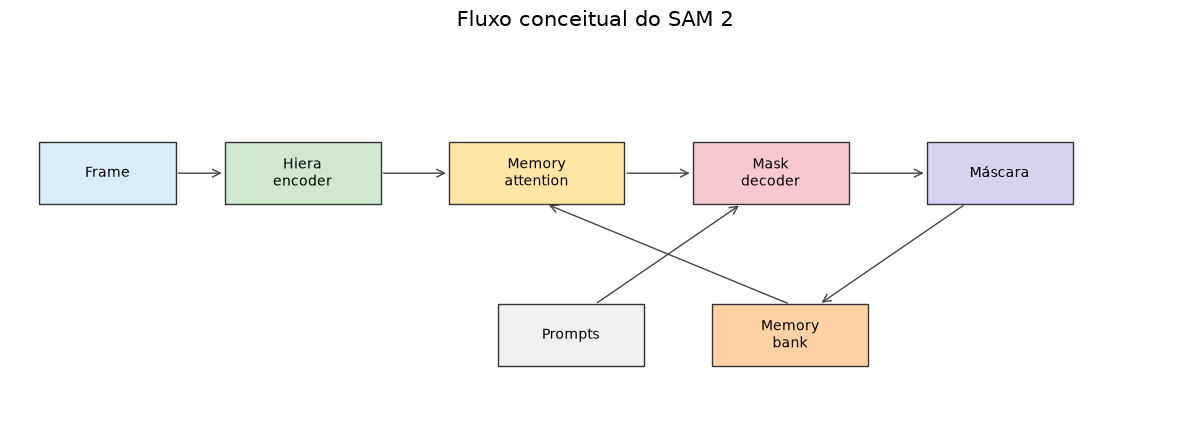

In [3]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Rectangle

fig, ax = plt.subplots(figsize=(12, 4.4))
ax.set_xlim(0, 12)
ax.set_ylim(0, 5)
ax.axis("off")

blocks = {
    "Frame": (0.3, 2.8, 1.4, 0.8, "#d9edf7"),
    "Hiera\nencoder": (2.2, 2.8, 1.6, 0.8, "#cfe8cf"),
    "Memory\nattention": (4.5, 2.8, 1.8, 0.8, "#ffe6a7"),
    "Mask\ndecoder": (7.0, 2.8, 1.6, 0.8, "#f7c8d0"),
    "Máscara": (9.4, 2.8, 1.5, 0.8, "#d8d1f0"),
    "Prompts": (5.0, 0.7, 1.5, 0.8, "#f0f0f0"),
    "Memory\nbank": (7.2, 0.7, 1.6, 0.8, "#ffd2a6"),
}
for label, (x, y, width, height, color) in blocks.items():
    ax.add_patch(Rectangle((x, y), width, height, facecolor=color, edgecolor="#333"))
    ax.text(x + width / 2, y + height / 2, label, ha="center", va="center", fontsize=10)

arrows = [
    ((1.7, 3.2), (2.2, 3.2)), ((3.8, 3.2), (4.5, 3.2)),
    ((6.3, 3.2), (7.0, 3.2)), ((8.6, 3.2), (9.4, 3.2)),
    ((6.0, 1.5), (7.5, 2.8)), ((8.0, 1.5), (5.5, 2.8)),
    ((9.8, 2.8), (8.3, 1.5)),
]
for start, end in arrows:
    ax.add_patch(FancyArrowPatch(start, end, arrowstyle="->", mutation_scale=14, color="#444"))

ax.set_title("Fluxo conceitual do SAM 2", fontsize=15)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "sam2_architecture_overview.png", dpi=180, bbox_inches="tight")
plt.show()

## Contribuições e números principais

- O dataset SA-V contém 50,9 mil vídeos, 642,6 mil masklets e 35,5
  milhões de máscaras (Tabela 3).
- O data engine da Fase 3 reduz o tempo médio de anotação de 37,8 para
  4,5 segundos por frame: ganho de 8,4 vezes (Tabela 1).
- Na tarefa de imagem SA-23 com um clique, SAM 2 alcança 58,9 mIoU
  usando somente SA-1B, contra 58,1 do SAM; a velocidade publicada é
  130,1 contra 21,7 FPS em A100 (Tabela 5).
- Com prompt de máscara no primeiro frame, SAM 2 Hiera-L obtém 77,9
  $J\&F$ no MOSE e 78,4 no teste SA-V (Tabela 6).

Esses números serão reconstruídos e verificados no notebook 04.

In [4]:
headline = {
    "videos_sa_v": 50_900,
    "masklets_sa_v": 642_600,
    "masks_sa_v": 35_500_000,
    "annotation_speedup": 37.8 / 4.5,
    "image_fps_speedup": 130.1 / 21.7,
}
for key, value in headline.items():
    print(f"{key:>24}: {value:,.2f}")

             videos_sa_v: 50,900.00
           masklets_sa_v: 642,600.00
              masks_sa_v: 35,500,000.00
      annotation_speedup: 8.40
       image_fps_speedup: 6.00


## Limitações para interpretar os resultados

A demonstração local não substitui os benchmarks: o paper avalia 37
datasets de imagem e até 17 datasets de vídeo, usa protocolos próprios
de prompts e mede velocidade em A100. Também há limitações descritas
pelos surveys: custo de memória em vídeo longo, queda em domínios muito
diferentes do treinamento, ambiguidade de prompts e risco de propagação
de erros. Por isso, toda figura deste projeto identifica se contém
valores publicados, inferência SAM 2 local ou baseline didático.